This is the mother of all 'Work in Progress' documents as it currently is

Think of it like a messy desk. To you, it's messy - to me, it's organised chaos :D

If you want to skip to something that actually looks like it's doing something, skip nearer to the end with the section header 'LDA + VADER'

In [115]:
import pandas as pd
import numpy as np
import pickle
import time
import re
from newsdataapi import NewsDataApiClient
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.corpus import wordnet
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.model_selection import train_test_split
from nltk.tokenize import TreebankWordTokenizer
from nltk.stem import WordNetLemmatizer
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('vader_lexicon')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\lovet\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\lovet\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\lovet\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

### NewsData.io API

This below function makes a set number ofrepeated calls to the NewsData.io API, retrieve the results, and pickle them.

In [116]:
api = NewsDataApiClient(apikey="pub_7778e8573b82439795e6a1ae9b9fef79")

def get_API_results(startFrom, finishAt):
    i = startFrom
    while i < finishAt:
        # call the API
        response = api.latest_api(country='nz',language='en')
        # appending the loop count to the filename so it doesn't write over the same file repeatedly
        filename = "Pickles/newsdata_latest_nz_0" + str(i) + ".pkl" 
        # Pickling the response
        with open(filename, 'wb') as f:
            pickle.dump(response, f)
        # print out a message so we know how far along in the loop it is
        print(f"completed: {i}")
        # Increment i so the loop eventually stops (see while condition)
        i += 1  
        # 300 seconds = 5 minutes before starting the loop again
        time.sleep(300) 

### get_API_results(1,51) 
# Warning: this function is currently commented out so it's only run intentionally (ie when actually needed), and not started by accident
# Running this function doesn't 'break' anything, but it is a needy resource hog
# If it's run, you will not be able to do literally anything else in this Notebook until it's either stopped or finishes what it's doing

In [117]:
#get_API_results(351,371) 

`frameify_results()` is a function for turning the pickles into rows to be appended to a dataframe

In [118]:
def frameify_results(theseresults):
    training_df = pd.DataFrame(columns=['Date','Source','Title','Description','page_url'])
    results_list = []
    for i in theseresults:

        # 1. Handle Keywords
        keywords = i['keywords']
        keywords = ' '.join(keywords) if isinstance(keywords, list) else str(keywords or '')
        
        html_text = i['description'] or ''
        clean_text = re.sub(r'<.*?>', '', html_text)

        new_row = {
            'Date': i['pubDate'], 
            'Source': i['source_id'], 
            'Title':i['title'],
            'Description': clean_text.strip(),
            'Keywords' : keywords.strip(),
            'page_url':i['link']
            }
        results_list.append(new_row)
    new_df = pd.DataFrame(results_list)
    training_df = pd.concat([training_df,new_df],axis=0)
    return training_df

Below is the code for reading aaaaaallll of the pickles back in again, and plopping them all in the dataframe (each pickle seems to come with 10 results).

In [119]:
# Initialising the dataframe for filling with the training data
training_df = pd.DataFrame(columns=['Date','Source','Title','Description','Keywords','page_url'])

def readNewsPickles(thismany):
    newsPickleFiles = []
    numPickles = thismany
    newsPickles = []

    for i in range(9):
        # appending the loop count to the filename so it adds the current number to the string
        # they all follow the same naming convention - I renamed a few to make sure of it
        filename = "Pickles/newsdata_latest_nz_00" + str(i+1) + ".pkl" 
        newsPickleFiles.append(filename)

    for i in range(9,numPickles):
        # appending the loop count to the filename so it adds the current number to the string
        # they all follow the same naming convention - I renamed a few to make sure of it
        filename = "Pickles/newsdata_latest_nz_0" + str(i+1) + ".pkl" 
        newsPickleFiles.append(filename)

    for item in newsPickleFiles:
        with open(item, 'rb') as file:
            pickled = pickle.load(file)
            newsPickles.append(frameify_results(pickled['results']))
    
    return pd.concat(newsPickles,axis=0)    

In [120]:
training_df = readNewsPickles(370)
training_df.reset_index(inplace=True)
training_df.drop(columns='index', inplace=True)

And then just checking to see what the data is looking like...

In [121]:
print(f"training_df rows: {training_df.shape[0]}, columns: {training_df.shape[1]}")
training_df.dtypes

training_df rows: 3700, columns: 6


Date           object
Source         object
Title          object
Description    object
page_url       object
Keywords          str
dtype: object

Giving the columns more appropriate data types

In [122]:
training_df['Date'] = pd.to_datetime(training_df['Date'])
training_df['Source'] = training_df['Source'].astype(str)
training_df['Title'] = training_df['Title'].astype(str)
training_df['Description'] = training_df['Description'].astype(str)
training_df['page_url'] = training_df['page_url'].astype(str)
training_df.dtypes

Date           datetime64[us]
Source                    str
Title                     str
Description               str
page_url                  str
Keywords                  str
dtype: object

In [123]:
print(f"training_df rows: {training_df.shape[0]}, columns: {training_df.shape[1]}")
# Check for NaNs
print(training_df.isna().sum())

training_df rows: 3700, columns: 6
Date           0
Source         0
Title          0
Description    0
page_url       0
Keywords       0
dtype: int64


Drop any duplicates

In [124]:
# Drop duplicates
training_df.drop_duplicates(inplace=True)
training_df.shape

(1208, 6)

Taking a peek at the sources

In [125]:
training_df['Source'].unique()

<StringArray>
['channellife_co_nz',     'onenews_co_nz',          'nzherald',
            'nzcity',     'cfotech_co_nz',    'thepress_co_nz',
        'thepost_nz',             'stuff',        'newstalkzb',
         'rnz_co_nz',              'btob',      'techradar_nz',
   'prnewswire_apac',   'waikatotimes_nz',     'itbrief_co_nz',
               'nbr',       'stuff_co_nz',   'neuseeland_news',
          'times_nz',    'nzherald_co_nz',   'indianweekender',
       'icc_cricket', 'thepeninsulaqatar',  'computerworld_nz',
      'miningweekly',     'teawamutunews',       'theguardian',
          'newsroom',      'espncricinfo',   'theconversation',
      'localmatters']
Length: 31, dtype: str

Looks like a couple of 'em are in there under different names, so let's tidy that a bit, and then do a quick plot just to see their representation in the dataframe

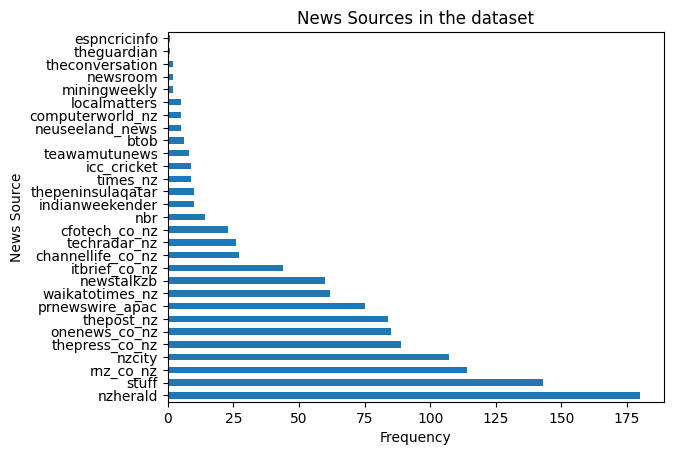

In [126]:
# tidying a couple of the sources
training_df.loc[training_df['Source'].str.contains('nzherald'), 'Source'] = 'nzherald'
training_df.loc[training_df['Source'].str.contains('stuff'), 'Source'] = 'stuff'

# plot the sources
training_df['Source'].value_counts().plot(kind='barh')
plt.title('News Sources in the dataset'); plt.xlabel('Frequency'); plt.ylabel('News Source'); plt.show()

## LDA Modeling

Table 1: Documents needed to recover topics and topics proportions
<table>
<tr>
    <td></td>
    <th colspan=10>Average essay length (in words)</th>
</tr>
<tr>
    <th>K topics</th>
    <td>10</td>
    <td>20</td>
    <td>25</td>
    <td>40</td>
    <td>50</td>
    <td>75</td>
    <td>100</td>
    <td>200</td>
    <td>250</td>
    <td>500</td>
</tr>
<tr>
    <td>2</td>
    <td>800</td>
    <td>240</td>
    <td>325</td>
    <td>220</td>
    <td>170</td>
    <td>75</td>
    <td>85</td>
    <td>55</td>
    <td>55</td>
    <td>55</td>
</tr>
<tr>
    <td>3</td>
    <td>1600</td>
    <td>800</td>
    <td>750</td>
    <td>600</td>
    <td>425</td>
    <td>240</td>
    <td>190</td>
    <td>85</td>
    <td>95</td>
    <td>55</td>
</tr>
<tr>
    <td>4</td>
    <td>2200</td>
    <td>1700</td>
    <td>1300</td>
    <td>950</td>
    <td>750</td>
    <td>425</td>
    <td>425</td>
    <td>160</td>
    <td>130</td>
    <td>65</td>
</tr>
<tr>
    <td>5</td>
    <td>3200</td>
    <td>2700</td>
    <td>1900</td>
    <td>1400</td>
    <td>1300</td>
    <td>1100</td>
    <td>650</td>
    <td>325</td>
    <td>180</td>
    <td>110</td>
</tr>
<tr>
    <td>6</td>
    <td>4400</td>
    <td>3000</td>
    <td>2500</td>
    <td>1800</td>
    <td>1500</td>
    <td>950</td>
    <td>750</td>
    <td>350</td>
    <td>300</td>
    <td>150</td>
</tr>
<tr>
    <td>7</td>
    <td>5000</td>
    <td>3700</td>
    <td>2900</td>
    <td>2200</td>
    <td>2000</td>
    <td>1500</td>
    <td>800</td>
    <td>375</td>
    <td>350</td>
    <td>190</td>
</tr>
<tr>
    <td>8</td>
    <td>6400</td>
    <td>4000</td>
    <td>4000</td>
    <td>2900</td>
    <td>2400</td>
    <td>1800</td>
    <td>1200</td>
    <td>600</td>
    <td>450</td>
    <td>200</td>
</tr>
<tr>
    <td>9</td>
    <td>7200</td>
    <td>5500</td>
    <td>4500</td>
    <td>3300</td>
    <td>2700</td>
    <td>1600</td>
    <td>1600</td>
    <td>600</td>
    <td>550</td>
    <td>275</td>
</tr>
<tr>
    <td>10</td>
    <td>9500</td>
    <td>6600</td>
    <td>5300</td>
    <td>4100</td>
    <td>3200</td>
    <td>2300</td>
    <td>1800</td>
    <td>800</td>
    <td>600</td>
    <td>300</td>
</tr>
</table>

Note. Adapted/Reprinted from [Sample Size for Latent Dirichlet Allocation of Constructed-Response Items](https://link.springer.com/chapter/10.1007/978-3-030-74772-5_24), by Wheeler, J.M., Cohen, A.S., Xiong, J., Lee, J., Choi, HJ. p263-267, [Quantitative Psychology](https://link.springer.com/book/10.1007/978-3-030-74772-5), 2021.

Let's check on word counts for the descriptions

In [127]:
training_df['description_word_count'] = training_df['Description'].str.split().str.len()
min_desc_words = training_df['description_word_count'].min()
max_desc_words = training_df['description_word_count'].max()
avg_desc_words = training_df['description_word_count'].mean()

print(f"Min word count: {min_desc_words}, Max word count: {max_desc_words}, Average word count: {avg_desc_words}")
training_df.shape


Min word count: 0, Max word count: 872, Average word count: 29.695364238410598


(1208, 7)

Restrict the dataset to rows where the description has a minimum word count of 10

In [128]:
training_df = training_df[training_df['description_word_count'] >= 10] # Keep rows that have a description word count higher than 10
min_desc_words = training_df['description_word_count'].min()
max_desc_words = training_df['description_word_count'].max()
avg_desc_words = training_df['description_word_count'].mean()

print(f"Min word count: {min_desc_words}, Max word count: {max_desc_words}, Average word count: {avg_desc_words}")
training_df.shape

Min word count: 10, Max word count: 872, Average word count: 30.300592718035563


(1181, 7)

## LDA Modeling, Attempt #1
Now that the data is collected, it will (hopefully) be used to train the model.

In [129]:
# Bring in the context
NZnewsdata = training_df['Description']
# Load the default English stop words
stop_words = stopwords.words('english')
# additional stop words
nzstopwords = ['news', 'national', 'audio', 'radio', 'co', 'nz', 'rnz', 'new', 'bay', 'plenty', 'hi','2025','women','men', 'streaming','stream',
'tauranga', 'howick', 'wellington','canterbury', 'auckland','christchurch','premium','27','podcasts','agoda','inc','te','warkworth','rotorua',
'transport','marlborough','nelson', 'dunedin', 'west','latest','ltd','tv','media','current','affairs','zealand','otago','tuhi','walk','run',
'cuisinemagazine', 'taranaki', 'southland', 'manawatu', 'wanganui', 'quot', '2025','2026','nbsp','39','said','also','across','would','head',
'get','name','names','u','k']
stop_words.extend(nzstopwords)
stop_words = list(stop_words)

# Initialise the LDA for 5 topics (n_components is the number of topics it generates)
lda = LatentDirichletAllocation(n_components=5, random_state=42) 
# Convert text to a Count Matrix for use with LDA (Vectorize while removing stop words)
vectorizer = CountVectorizer(stop_words=stop_words)
news_term_matrix = vectorizer.fit_transform(NZnewsdata)

### Fit and transform the model
- `fit_transform()` takes the topics to model (in this case NZnewsdata, which is the variable for training_df['Description'])
- `fit()` and `tranform()` both take the vectorised data after `fit_tranform()` has been applied to it

In [130]:
# Fit and Transform the LDA model
lda_output = lda.fit_transform(news_term_matrix)

lda_topics = lda.transform(news_term_matrix)

Quick check to make sure the parameters it's accepting/expecting are the same length

In [131]:
print("Vectorizer features:", news_term_matrix.shape[1])
print("LDA expected features:", lda.components_.shape[1])

Vectorizer features: 7040
LDA expected features: 7040


In [132]:
# Print top words for each topic
words = vectorizer.get_feature_names_out()
for topic_idx, topic in enumerate(lda.components_):
    print(f"\nTopic #{topic_idx}:")
    print([words[i] for i in topic.argsort()[:-6:-1]])


Topic #0:
['year', 'ai', 'old', 'people', 'says']

Topic #1:
['al', 'year', 'one', 'old', 'first']

Topic #2:
['may', 'data', 'says', 'first', 'year']

Topic #3:
['may', 'prnewswire', 'ai', 'south', 'us']

Topic #4:
['ai', 'year', 'apple', 'one', 'company']


### LDA Modeling, Attempt #2
The 'topics' the initial attempt's model has come up with aren't very descriptive/interpretable, and likely can't be used in practice.

Instead of just the description for those articles, let's try feeding it the entirety of some articles from that initial retrieval.

In [133]:
# exporting urls the API retrieved so I can (manually) go and get some articles
page_urls = training_df[['Source','page_url']]
page_urls.to_csv('Datasets/news_urls.csv')

In [134]:
# Then bring in the full articles that I've collected so far
news_training_df = pd.read_excel('Datasets/FullNewsArticles50.xlsx')
news_content = news_training_df['Description']
news_content = news_content.str.replace('\n', ' ', regex=False) # get rid of newline characters
print(f"Articles: {news_content.shape[0]}")

Articles: 50


In [135]:
morestopwords = ['fullerton','noah','singh','rbnz','rieben','joksimovic','boem','jones','year','hat','red','6pm','one','made','velden',
'kururangi','soul','van','thursday','really','finau','well','role','going','could','three']
stop_words.extend(morestopwords)
brandstopwords = ['toyota','ibm','crowdstrike','hylo','genetec','tigers','amisfield','ansible','quiltworks','bsa','nzta','inland','000']
stop_words.extend(brandstopwords)

# Initialise a (new) LDA
lda2 = LatentDirichletAllocation(n_components=5, random_state=42) 
# Convert text to a Count Matrix for use with LDA (Vectorize while removing stop words)
vectorizer2 = CountVectorizer(stop_words=stop_words)
news_term_matrix2 = vectorizer2.fit_transform(news_content)

# Fit and Transform the LDA model
lda_output = lda2.fit_transform(news_term_matrix2)
lda_topics = lda2.transform(news_term_matrix2)

# Check what we got is accepted/expected (these both need to be printing the same number)
print("Vectorizer features:", news_term_matrix2.shape[1])
print("LDA expected features:", lda2.components_.shape[1])

Vectorizer features: 4634
LDA expected features: 4634


In [136]:
# Print top words for each topic
words = vectorizer2.get_feature_names_out()
for topic_idx, topic in enumerate(lda2.components_):
    print(f"\nTopic #{topic_idx}:")
    print([words[i] for i in topic.argsort()[:-6:-1]])


Topic #0:
['test', 'brand', 'citizenship', 'data', 'us']

Topic #1:
['coroner', 'court', 'force', 'people', 'may']

Topic #2:
['bridge', 'work', 'automation', 'construction', 'business']

Topic #3:
['government', 'local', 'risk', 'cyber', 'data']

Topic #4:
['quarter', 'unemployment', 'rate', 'people', 'labour']


### Perplexity
Whether or not the model is doing well can be measured by its perplexity score for each topic.

Perplexity tells us whether or not the model is effectively being "surprised" by what words come next versus what its expecting for each topic. Low perplexity is good (this means there's not too many suprises), high perplexity is bad (it is being bamboozled).

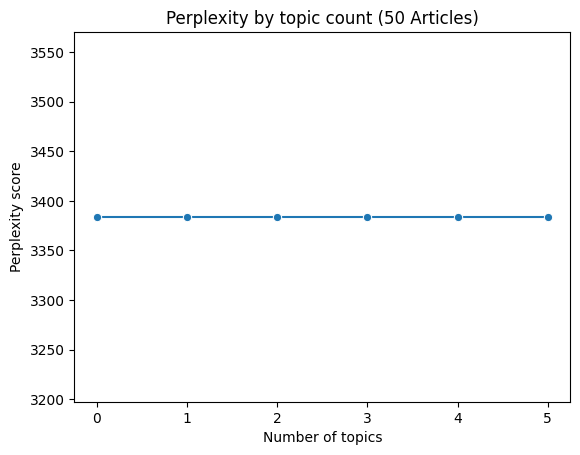

In [137]:
perplexity_score = []
topic_nums = range(6)

for topics in topic_nums:
    lda2.fit(news_term_matrix2)
    perplexity_score.append(lda2.perplexity(news_term_matrix2))  

# Plot perplexity by topic count
ax = sns.lineplot(x = topic_nums, y = perplexity_score, marker = 'o')
ax.set_title('Perplexity by topic count (50 Articles)')
ax.set_ylabel('Perplexity score'); ax.set_xlabel('Number of topics')
plt.show()

Good news / bad news
- Good news: the line is constant so the perplexity is consistent across all topics
- Bad news: The score is consistently very high - thus, very bad - across all topics.

### LDA Modeling, Attempt #3
Let's give it some more articles to work with.

In [138]:
# Bringing in the original article set plus more collected
news_training_df2 = pd.read_excel('Datasets/FullNewsArticles190.xlsx')
news_content2 = news_training_df2['Description']
news_content2 = news_content2.str.replace('\n', ' ', regex=False) # get rid of newline characters

In [139]:
def preprocess_text(text):
    text = re.sub('\'\n', '', text)  # Remove apostrophes and newlines
    text = re.sub('[^a-zA-Z]', ' ', text)  # Remove non-alphabet characters
    text = text.lower()  # Convert to lowercase
    return text

news_training_df2['Content'] = news_training_df2['Description'].apply(preprocess_text)
news_content3 = news_training_df2['Content']

### Train, Test, Split
Because LDA is an unsupervised learning model, we do not need both an x (features/independent) and y (dependent) variable for train_test_split.
- `test_size` is how much of the data we're splitting off for testing (in this case, 0.2, or 20%)
- `random_state` is like set seed - if we were to run this test again, with the same random state, it would give the same split. For a different split, choose a different value for random_state

In [140]:
X_train, X_test = train_test_split(news_content3, test_size=0.2, random_state=19)
print(f"Articles (training): {X_train.shape[0]}")
print(f"Articles (testing): {X_test.shape[0]}")

Articles (training): 152
Articles (testing): 38


In [141]:
news_content2.head()

0    The past few weeks have resulted in some major...
1    CrowdStrike has expanded Project QuiltWorks an...
2    The Government is set to introduce a new citiz...
3    A salon chair chat between Rotorua schoolmates...
4    The All Whites will play Haiti for the first t...
Name: Description, dtype: str

In [142]:
# Introducing some more stop words
evenmorestopwords = ['says','two','act','davey','turner','last','local','brand','days','told','freda',
'like','percent','wa', 'ha','say','day','medium']
stop_words.extend(evenmorestopwords)

# Initialise a(nother) LDA
lda3 = LatentDirichletAllocation(n_components=5, random_state=42) 
# Convert text to a Count Matrix for use with LDA (Vectorize while removing stop words)
vectorizer3 = CountVectorizer(stop_words=stop_words)
news_term_matrix3 = vectorizer3.fit_transform(X_train)

# Fit and Transform the LDA model
lda_output = lda3.fit_transform(news_term_matrix3)
lda_topics = lda3.transform(news_term_matrix3)

# Check what we got is accepted/expected (these both need to be printing the same number)
print("Vectorizer features:", news_term_matrix3.shape[1])
print("LDA expected features:", lda3.components_.shape[1])

Vectorizer features: 9428
LDA expected features: 9428


In [143]:
# Print top words for each topic
words = vectorizer3.get_feature_names_out()
for topic_idx, topic in enumerate(lda3.components_):
    print(f"\nTopic #{topic_idx}:")
    print([words[i] for i in topic.argsort()[:-6:-1]])


Topic #0:
['people', 'young', 'bridge', 'government', 'time']

Topic #1:
['us', 'iran', 'trump', 'war', 'strait']

Topic #2:
['rugby', 'time', 'first', 'years', 'pigs']

Topic #3:
['people', 'government', 'community', 'council', 'rugby']

Topic #4:
['people', 'council', 'court', 'time', 'work']


In [144]:
perplexity_score = []
topic_nums = range(6)

for topics in topic_nums:
    lda3.fit(news_term_matrix3)
    perplexity_score.append(lda3.perplexity(news_term_matrix3))  

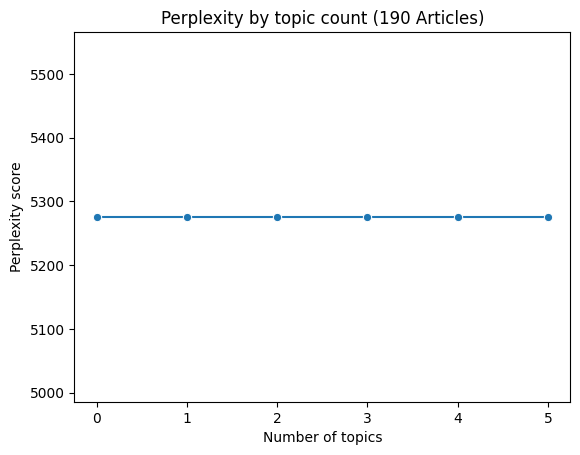

In [145]:
# Plot perplexity by topic count
ax = sns.lineplot(x = topic_nums, y = perplexity_score, marker = 'o')
ax.set_title('Perplexity by topic count (190 Articles)')
ax.set_ylabel('Perplexity score'); ax.set_xlabel('Number of topics')
plt.show()

Somehow, giving it more data just... confused it more?

### LDA Modeling, Attempt #4
Let's see if we can improve those perplexity scores a bit by doing some fine-tuning

Vectorizer change:
- `min_df` parameter tells it to discard tokens (words) that appear less than n amount of times across all documents

Preprocessing/tokenisation:
- Lemmatisation (where the words are stripped down to their root form, ie 'running' becomes 'run')

Stopwords:
- Started a new stopword library and let this one have a whole bunch of the context words that'd been taken away from it before
- Notably, this caused the biggest improvement to the perplexity scoring

In [146]:
# DEFINITIONS
lemmatizer = WordNetLemmatizer()
tokenizer = TreebankWordTokenizer()

# This function is for identifying/tagging different parts of speech in the text
def get_wordnet_pos(treebank_tag):
    # Function to map Treebank POS tags to WordNet POS tags
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN # Default to noun

# This function is for lemmatization (which improves when the parts of speech are tagged accordingly, 
# otherwise it defaults to treating everything as a Noun)
def lemmatize_tokenizer(text):   
    tokens = tokenizer.tokenize(str(text))
    # 3. Apply POS Tagging & Lemmatization
    lemmatized = [lemmatizer.lemmatize(token, get_wordnet_pos(tag)) 
                  for token, tag in nltk.pos_tag(tokens)]
    return " ".join(lemmatized)

# Preprocessing and lemmatizing
news_training_df2['Content'] = news_training_df2['Description'].apply(preprocess_text)
news_training_df2['Content'].astype(str).apply(lemmatize_tokenizer)

news_content4 = news_training_df2['Content']

X_train2, X_test2 = train_test_split(news_content4, test_size=0.2, random_state=25)

print(f"Articles (training): {X_train2.shape[0]}")
print(f"Articles (testing): {X_test2.shape[0]}")

Articles (training): 152
Articles (testing): 38


In [147]:
stopset = stopwords.words('english')
addtostopset = ['nzta','one','two','first','years','three','singh']
stopset.extend(addtostopset)

# Initialise a(nother) LDA
lda4 = LatentDirichletAllocation(n_components=5, random_state=42) 
# Convert text to a Count Matrix for use with LDA (Vectorize while removing stop words)
vectorizer4 = CountVectorizer(stop_words=stopset,min_df = 2)
news_term_matrix4 = vectorizer4.fit_transform(X_train2)

# Fit and Transform the LDA model
lda_output_train = lda4.fit(news_term_matrix4)
lda_topics_train = lda4.transform(news_term_matrix4)

# Check what we got is accepted/expected (these both need to be printing the same number)
print("Vectorizer features:", news_term_matrix4.shape[1])
print("LDA expected features:", lda4.components_.shape[1])

Vectorizer features: 4640
LDA expected features: 4640


In [148]:
# Print top words for each topic
words = vectorizer4.get_feature_names_out()
for topic_idx, topic in enumerate(lda4.components_):
    print(f"\nTopic #{topic_idx}:")
    print([words[i] for i in topic.argsort()[:-15:-1]])


Topic #0:
['said', 'ai', 'new', 'across', 'data', 'also', 'management', 'security', 'systems', 'energy', 'organisations', 'council', 'business', 'work']

Topic #1:
['said', 'us', 'would', 'trump', 'climate', 'new', 'people', 'iran', 'strait', 'war', 'report', 'could', 'government', 'military']

Topic #2:
['year', 'said', 'time', 'new', 'people', 'rugby', 'says', 'zealand', 'last', 'unemployment', 'world', 'women', 'quarter', 'also']

Topic #3:
['said', 'new', 'rugby', 'year', 'zealand', 'people', 'game', 'kururangi', 'court', 'last', 'also', 'pigs', 'found', 'old']

Topic #4:
['said', 'new', 'would', 'people', 'year', 'zealand', 'also', 'percent', 'test', 'time', 'media', 'get', 'going', 'government']


In [149]:
perplexity_score = []
topic_nums = range(6)

for topics in topic_nums:
    lda4.fit(news_term_matrix4)
    perplexity_score.append(lda4.perplexity(news_term_matrix4))  

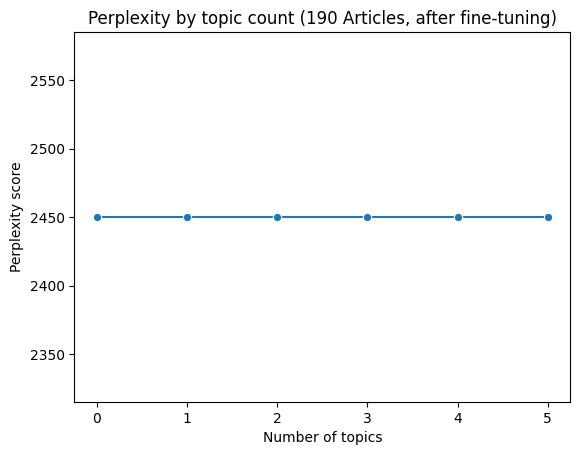

In [150]:
# Plot perplexity by topic count
ax = sns.lineplot(x = topic_nums, y = perplexity_score, marker = 'o')
ax.set_title('Perplexity by topic count (190 Articles, after fine-tuning)')
ax.set_ylabel('Perplexity score'); ax.set_xlabel('Number of topics')
plt.show()

### Train, Test, Split: The Test
Let's actually have a go at testing the trained model, this time, by applying it to new data it hasn't seen yet.
- Trained Vectorizer: `vectorizer4`
- Trained LDA: `lda4`
- New data: `X_test2`

In [151]:
# Use the trained vectorizer to transform new data
X_testing = vectorizer4.transform(X_test2) 

# Use the trained LDA model to get topic distributions
lda_topics_test = lda4.transform(X_testing)

# Get the perplexity scores again
perplexity_score_testers = []
topic_nums = range(6)

for topics in topic_nums:
    lda4.fit(lda_topics_test)
    perplexity_score_testers.append(lda4.perplexity(lda_topics_test))  

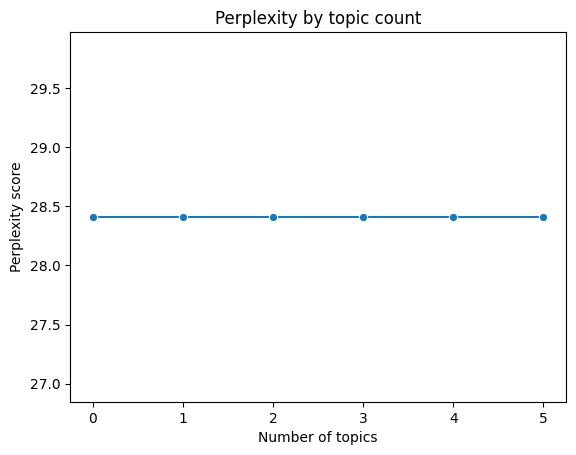

In [152]:
# Plot perplexity by topic count
ax = sns.lineplot(x = topic_nums, y = perplexity_score_testers, marker = 'o')
ax.set_title('Perplexity by topic count')
ax.set_ylabel('Perplexity score'); ax.set_xlabel('Number of topics')
plt.show()

Evidently, it's a whole lot less surprised by the new data than it was by the training data. That's, uh... that's not what I was expecting (is that supposed to happen?)

### Getting the dominant topic for each article

Process
1. Get the results of the 'dominant' topic for each article (ie. which topic does that article match most closely with)
2. Attach those results to their respective articles in the dataset

In [153]:
# Get the index of the topic with the highest probability for each document
dominant_topic_train = np.argmax(lda_topics_train, axis=1)
dominant_topic_test = np.argmax(lda_topics_test, axis=1)

# Create a DataFrame to view results clearly
df_dominant_topic_train = pd.DataFrame({
    'Document_ID': range(len(dominant_topic_train)),
    'Dominant_Topic': dominant_topic_train,
    'Topic_Probability': np.max(lda_topics_train, axis=1)
})

training_len = len(dominant_topic_train)
testing_len = len(dominant_topic_test)
starting_ind = training_len+1
end_at = training_len + testing_len +1

df_dominant_topic_test = pd.DataFrame({
    'Document_ID': range(starting_ind,end_at),
    'Dominant_Topic': dominant_topic_test,
    'Topic_Probability': np.max(lda_topics_test, axis=1)
})

df_dominant_topic_train.head(3)

,Document_ID,Dominant_Topic,Topic_Probability
0,0,0,0.998399
1,1,1,0.998748
2,2,0,0.595982


In [154]:
# Make a copy of the original dataset
news_training_df2_copy = news_training_df2.copy()



training_set =pd.concat([X_train2,df_dominant_topic_train],axis=1)
training_set.dropna(inplace=True)

testing_set =pd.concat([X_train2,df_dominant_topic_test],axis=1)
testing_set.dropna(inplace=True)

testing_set
# Attach the dominant topic to their respective articles
#dominant_topics_df = pd.concat([df_dominant_topic_train,df_dominant_topic_test], axis=0)

#dominant_topics_df.reset_index(inplace=True)
#dominant_topics_df.drop(columns='index')

#dominant_topics_df

nz_news_df = pd.concat([training_set,testing_set], axis=0)
nz_news_df.head(3)

,Content,Document_ID,Dominant_Topic,Topic_Probability
124,hpe has introduced new autonomous networking f...,124.0,4.0,0.996778
7,cdc data centres says it has secured a major c...,7.0,0.0,0.998570
107,the white ferns have beaten an england develop...,107.0,4.0,0.993124


In [155]:
topic_0_bestmatches = nz_news_df.loc[(nz_news_df['Dominant_Topic'] == 0) & (nz_news_df['Topic_Probability'] > 0.8)]
topic_0_bestmatches['Content']

7      cdc data centres says it has secured a major c...
105    you are  coming down with something   maybe yo...
91      in the afternoon  it gets hot at my desk    w...
73     the new zealand media awards have stripped voy...
0      the past few weeks have resulted in some major...
134    the elderly victim of a random alleged stabbin...
63     a toddler on the gold coast is in an induced c...
13     explainer   at clive s chemist in wainuiomata ...
76     russia is shifting from individual recruits to...
22     small and medium sized businesses are becoming...
130    steve lancaster has been appointed the new chi...
50     us defence secretary pete hegseth has denied r...
62     at the one minute and    second mark of netfli...
12     a new zealand food and wine magazine has dropp...
Name: Content, dtype: str

In [156]:
#topic_1_bestmatches = nz_news_df.loc[(nz_news_df['Dominant_Topic'] == 1) & (nz_news_df['Topic_Probability'] > 0.8)]
#topic_1_bestmatches['Title'] # Economy?

From the above topic "best matches" and their article titles, I don't think we're really getting coherent, distinguishable topics - everything's sort of... bleeding together.
The only one of the topics that's vaguely recognisable as anything would be Topic 1, which I would (very broadly) use the umbrella term of "Global Economy" for.


### LDA Modeling, Attempt #5

The goal from here can be summarised with two words: "More" and "Data"

I have put a mental pin in this and will revisit it later though because the excel files I'm trying to load in with the added articles are coming up with NaNs, and I cannot <em>even</em> with that right now.

In [157]:
# Bringing in the original article set plus additional collected
news_training_df3 = pd.read_excel('Datasets/FullNewsArticles283.xlsx')
# Preprocessing and lemmatizing
news_training_df3['Content'] = news_training_df2['Description'].apply(preprocess_text)
news_training_df3['Content'].astype(str).apply(lemmatize_tokenizer)
# storing content in its own variable
news_content5 = news_training_df3['Content']

In [158]:
news_content5[189]

'an incident where an interislander ferry lost power in the cook strait almost certainly would have ended in a serious casualty if not for a well timed anchor drop  a report says   an investigation into the dramatic kaitaki breakdown in      has also shown the response to the emergency was poorly structured and the co ordination between stakeholders during the rescue was lacking   the transport accident investigation commission  taic  today released its final report into the maritime incident  concluding the multi year inquiry   kiwirail was fined more than          for the mayday incident  which took place three years ago   at     pm on january           the operator advised maritime new zealand the kaitaki ferry had reported engine problems   the ferry lost power in the middle of the cook strait and drifted for an hour with     people on board    time was critical  and if the ship had not been arrested by its anchors  a very serious marine casualty was virtually certain   the report 

In [159]:
news_content5[190]

nan

In [160]:
news_content5[260]

nan

# LDA + VADER

Let's just get on with VADER and go back to the LDA later.

Consider this next bit the absolute 'work in progress' of all work-in-progresses. This isn't what it'll look like when it's done, this is just setting up the bones of it so we know (at least some of) what we're doing after the LDA

In [161]:
def frameify_pickles(theseresults):
    training_df = pd.DataFrame(columns=['Date','Source','Title','Description','page_url'])
    results_list = []
    for i in theseresults:
        
        html_text = i['description'] or ''
        clean_text = re.sub(r'<.*?>', '', html_text)

        # Fix the date time format (the API has it as something like 2020-04-20T22:11:00)
        api_date = i['publishedAt']
        formatted_date = api_date.split('T')[0]

        new_row = {
            'Date': formatted_date, 
            'Source': i['source']['name'], 
            'Title':i['title'],
            'Description': clean_text.strip(),
            'page_url':i['url']
            }
        results_list.append(new_row)
    new_df = pd.DataFrame(results_list)
    training_df = pd.concat([training_df,new_df],axis=0)
    return training_df

In [162]:
def readNewsAPIPickles(thismany):
    newsPickleFiles = []
    numPickles = thismany
    newsPickles = []

    for i in range(numPickles):
        # appending the loop count to the filename so it adds the current number to the string
        # they all follow the same naming convention - I renamed a few to make sure of it
        filename = "Pickles/newsapi_geteverything" + str(i+1) + ".pkl" 
        newsPickleFiles.append(filename)

    for item in newsPickleFiles:
        with open(item, 'rb') as file:
            pickled = pickle.load(file)
            newsPickles.append(frameify_pickles(pickled['articles']))
    
    return pd.concat(newsPickles,axis=0)   

In [163]:
bones_df = readNewsAPIPickles(2)
bones_df.reset_index(inplace=True)
bones_df.drop(columns='index',inplace=True)

# Preprocessing and lemmatizing
bones_df['Content'] = bones_df['Description'].apply(preprocess_text)
bones_df['Content'].astype(str).apply(lemmatize_tokenizer)

bones_content = bones_df['Content']

In [164]:
# Bring in the version of the LDA + vectorizer we're working with (for now)
# Trained OG vectorizer to transform new data
bones_matrix = vectorizer.transform(bones_content) 

# Trained OG LDA for the new vectorized data
bones_topics = lda.transform(bones_matrix)

perplexity_score = []
topic_nums = range(6)

for topics in topic_nums:
    lda.fit(bones_matrix)
    perplexity_score.append(lda.perplexity(bones_matrix))  

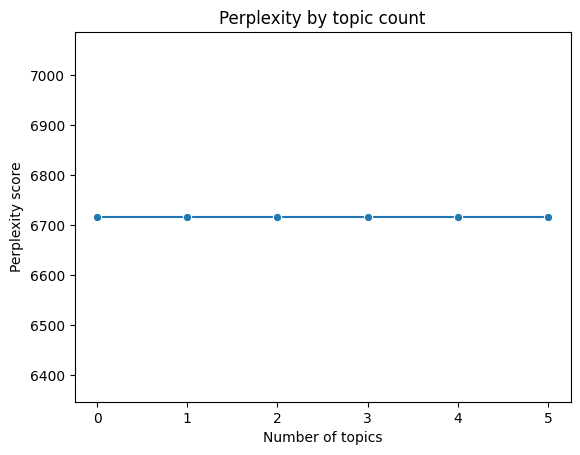

In [165]:
# Plot perplexity by topic count
ax = sns.lineplot(x = topic_nums, y = perplexity_score, marker = 'o')
ax.set_title('Perplexity by topic count')
ax.set_ylabel('Perplexity score'); ax.set_xlabel('Number of topics')
plt.show()

In [166]:
# Get the index of the topic with the highest probability for each document
dominant_topic_bones = np.argmax(bones_topics, axis=1)

# Create a DataFrame to view results clearly
df_dominant_topic_bones = pd.DataFrame({
    'Article_ID': range(len(dominant_topic_bones)),
    'Dominant_Topic': dominant_topic_bones,
    'Topic_Probability': np.max(bones_topics, axis=1)
})

df_dominant_topic_bones.head(1)

,Article_ID,Dominant_Topic,Topic_Probability
0,0,3,0.817036


In [167]:
# Patch the dominant topics in with the corresponding rows
bones_joined_df = pd.concat([bones_df,df_dominant_topic_bones], axis = 1)
bones_joined_df.head(1)

,Date,Source,Title,Description,page_url,Content,Article_ID,Dominant_Topic,Topic_Probability
0,2026-05-06,Gizmodo.com,Alaska’s Famous Fjords Are Becoming a Cruise S...,Climate change is making landslides and tsunam...,https://gizmodo.com/alaskas-famous-fjords-are-...,climate change is making landslides and tsunam...,0,3,0.817036


In [168]:
analyzer = SentimentIntensityAnalyzer()

# Apply sentiment analysis to each row
bones_joined_df['VADER_sentiment'] = bones_joined_df['Content'].apply(lambda x: analyzer.polarity_scores(x))

bones_joined_df.head(1)

,Date,Source,Title,Description,page_url,Content,Article_ID,Dominant_Topic,Topic_Probability,VADER_sentiment
0,2026-05-06,Gizmodo.com,Alaska’s Famous Fjords Are Becoming a Cruise S...,Climate change is making landslides and tsunam...,https://gizmodo.com/alaskas-famous-fjords-are-...,climate change is making landslides and tsunam...,0,3,0.817036,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound..."


In [169]:
# Expand VADER's output list into separate columns in its own mini frame
sentiment_expanded_df = pd.DataFrame(bones_joined_df['VADER_sentiment'].tolist(), index=bones_joined_df.index)
# rename the cols so they can be eyeballed easy later
sentiment_expanded_df.rename(columns={"neg":'vader_neg',"neu":"vader_neu","pos":'vader_pos',"compound":'vader_compound'}, inplace=True)
# Join the miniframe onto the big boi frame
bones_joined_df = pd.concat([bones_joined_df,sentiment_expanded_df],axis=1)

# Check that all worked
bones_joined_df.head(1)

,Date,Source,Title,Description,page_url,Content,Article_ID,Dominant_Topic,Topic_Probability,VADER_sentiment,vader_neg,vader_neu,vader_pos,vader_compound
0,2026-05-06,Gizmodo.com,Alaska’s Famous Fjords Are Becoming a Cruise S...,Climate change is making landslides and tsunam...,https://gizmodo.com/alaskas-famous-fjords-are-...,climate change is making landslides and tsunam...,0,3,0.817036,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0,1.0,0.0,0.0


In [172]:
# Now let's pick one topic just to see what we've got to work with at this point

bones_topic3_df = bones_joined_df.loc[bones_joined_df['Dominant_Topic'] == 3]

# Put it into something I can work into a timeseries

# Group by 'Date' and then get the compound score (I guess?)
bones_topic3_dtvader = bones_topic3_df.groupby('Date').agg(Compound_score = ('vader_compound', 'mean'))
bones_topic3_dtvader.reset_index(inplace=True)
bones_topic3_dtvader.head(5)

,Date,Compound_score
0,2026-04-12,0.855500
1,2026-04-13,0.612300
2,2026-04-15,0.883400
3,2026-04-16,0.557400
4,2026-04-17,0.077133


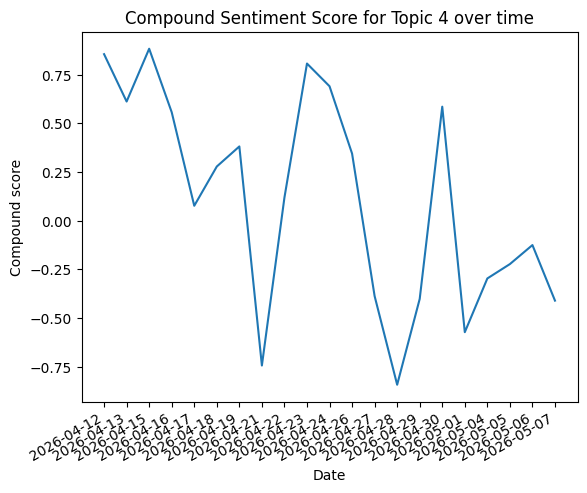

In [174]:
# Plotting the time series for Topic 4
plt.plot(bones_topic3_dtvader['Date'], bones_topic3_dtvader['Compound_score'])

# rotating the x-axis tick labels for readability
plt.xticks(rotation=30, ha='right')

# Add title
plt.title('Compound Sentiment Score for Topic 4 over time')

# Add appropriate x and y labels
plt.xlabel('Date')
plt.ylabel('Compound score')

plt.show()